# 05 -- Anomaly Detection
### Task 4 (weight 10%)

**Goal:** identify abnormal equipment behavior -- power spikes, excessive vibration,
sensor drift, degradation onset -- via a **four-method framework**, each method mapped to
the anomaly/fault archetype that actually produces that shape in the data (see
`physics.py`), not a single detector applied blindly everywhere:

| Method | Catches | Why this method |
|---|---|---|
| **Statistical thresholding** (seasonal MAD z-score) | Power spikes, sharp point anomalies | Transparent, per-signal, explainable to technicians |
| **Isolation Forest** | Subtle joint-pattern anomalies (drift, unusual combos) | Learns normal behavior across all sensors at once |
| **CUSUM** | Slow, sustained sensor drift | Point thresholds can't catch a drift that never produces one big jump |
| **Change-point detection** (ruptures) | Degradation onset (regime shift) | Flags exactly *when* an asset's statistical behavior shifted |

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from nectar import config, preprocessing, anomaly
sns.set_theme(style='whitegrid')
FIG = config.FIGURES_DIR
raw = preprocessing.load_raw()

## 1. Statistical thresholding

**Design note (an actual bug found and fixed during development):** a plain time-window
rolling MAD z-score on `power_consumption` initially flagged 21-32% of readings -- because
building/asset power is strongly bimodal (idle ~10% of full load vs. occupied full load),
so *any* window spanning a day/night transition sees most of its own points as "outliers"
relative to that window's median. Comparing each reading against its own **hour-of-day**
baseline instead (`anomaly.seasonal_mad_z`) fixes this and correctly separates expected
diurnal shape from genuine anomalies. Vibration/temperature don't have this bimodality
problem and keep the simpler time-window rolling z-score.

In [2]:
stat = anomaly.statistical_flags(raw['telemetry'])
stat = stat.merge(raw['metadata'][['asset_id','asset_type']], on='asset_id')
print(f"Statistical anomalies: {stat.stat_anomaly.sum():,} ({stat.stat_anomaly.mean()*100:.2f}%)")
stat.groupby('asset_type')['stat_anomaly'].mean().mul(100).round(2)

Statistical anomalies: 43,314 (2.21%)


asset_type
AHU            4.87
Chiller        3.84
EnergyMeter    1.16
EnvSensor      0.00
Pump           1.30
Name: stat_anomaly, dtype: float64

## 2. Isolation Forest (multivariate)

In [3]:
iso = anomaly.isolation_forest_flags(raw['telemetry'], raw['metadata'])
print(f"Isolation Forest anomalies: {iso.iso_anomaly.sum():,} ({iso.iso_anomaly.mean()*100:.2f}%)")

Isolation Forest anomalies: 20,477 (2.00%)


## 3. CUSUM drift detection

**Same class of bug, same fix pattern as Method 1:** running CUSUM directly on raw
`temperature` (which has real diurnal structure) flagged 28-93% of readings, because a
fixed single-day baseline can't represent a genuinely cyclical signal -- the daily cycle
itself looked like permanent "drift". Deseasonalizing first (subtract each asset's own
hour-of-day median) then running CUSUM on the residual brings this down to a sparse,
plausible rate. The accumulator also now resets after firing (standard CUSUM behavior) --
without it, one alarm stayed "active" for the rest of the series.

In [4]:
cusum = anomaly.cusum_flags_all(raw['telemetry'])
cusum = cusum.merge(raw['metadata'][['asset_id','asset_type']], on='asset_id')
print(f"CUSUM drift anomalies: {cusum.cusum_anomaly.sum():,} ({cusum.cusum_anomaly.mean()*100:.2f}%)")
cusum.groupby('asset_type')['cusum_anomaly'].mean().mul(100).round(2)

CUSUM drift anomalies: 7,167 (0.37%)


asset_type
AHU            0.18
Chiller        1.79
EnergyMeter    0.00
EnvSensor      0.21
Pump           0.34
Name: cusum_anomaly, dtype: float64

## 4. Change-point detection (degradation onset)

Run per rotating asset on hourly-resampled vibration (10-min resolution is unnecessarily
fine-grained for this and much slower). **Binseg**, not `Pelt(jump=1)`: verified ~300x
faster (0.1s vs ~37s per asset) with comparable breakpoint counts -- the exact Pelt search
was costing over 50 minutes across all rotating assets, not viable for iteration.

In [5]:
cps = anomaly.changepoint_flags(raw['telemetry'], raw['metadata'])
n_assets_with_cps = len(cps)
n_total_cps = sum(len(v) for v in cps.values())
print(f"Change points found: {n_total_cps} across {n_assets_with_cps} assets")

Change points found: 92 across 79 assets


## 5. Validation -- does anomaly density rise near known faults?

In [6]:
lift = anomaly.validate_against_faults(iso, 'iso_anomaly', window_hours=24)
rate_near = lift.get(1.0, 0); rate_far = lift.get(0.0, 1e-9)
print(f"IsoForest anomaly rate within 24h of a fault: {rate_near*100:.2f}%")
print(f"IsoForest anomaly rate elsewhere:              {rate_far*100:.2f}%")
print(f"Lift: {rate_near/rate_far:.1f}x")

IsoForest anomaly rate within 24h of a fault: 4.92%
IsoForest anomaly rate elsewhere:              1.94%
Lift: 2.5x


This closes the loop with Task 2: anomaly flags are measurably more frequent in the
run-up to a known fault than during normal operation, confirming the detector captures
genuine equipment degradation rather than random noise -- an independent validation of
the same physical signal Task 2's model learns to predict.

## 6. Visualization -- example asset timeline, all four methods overlaid

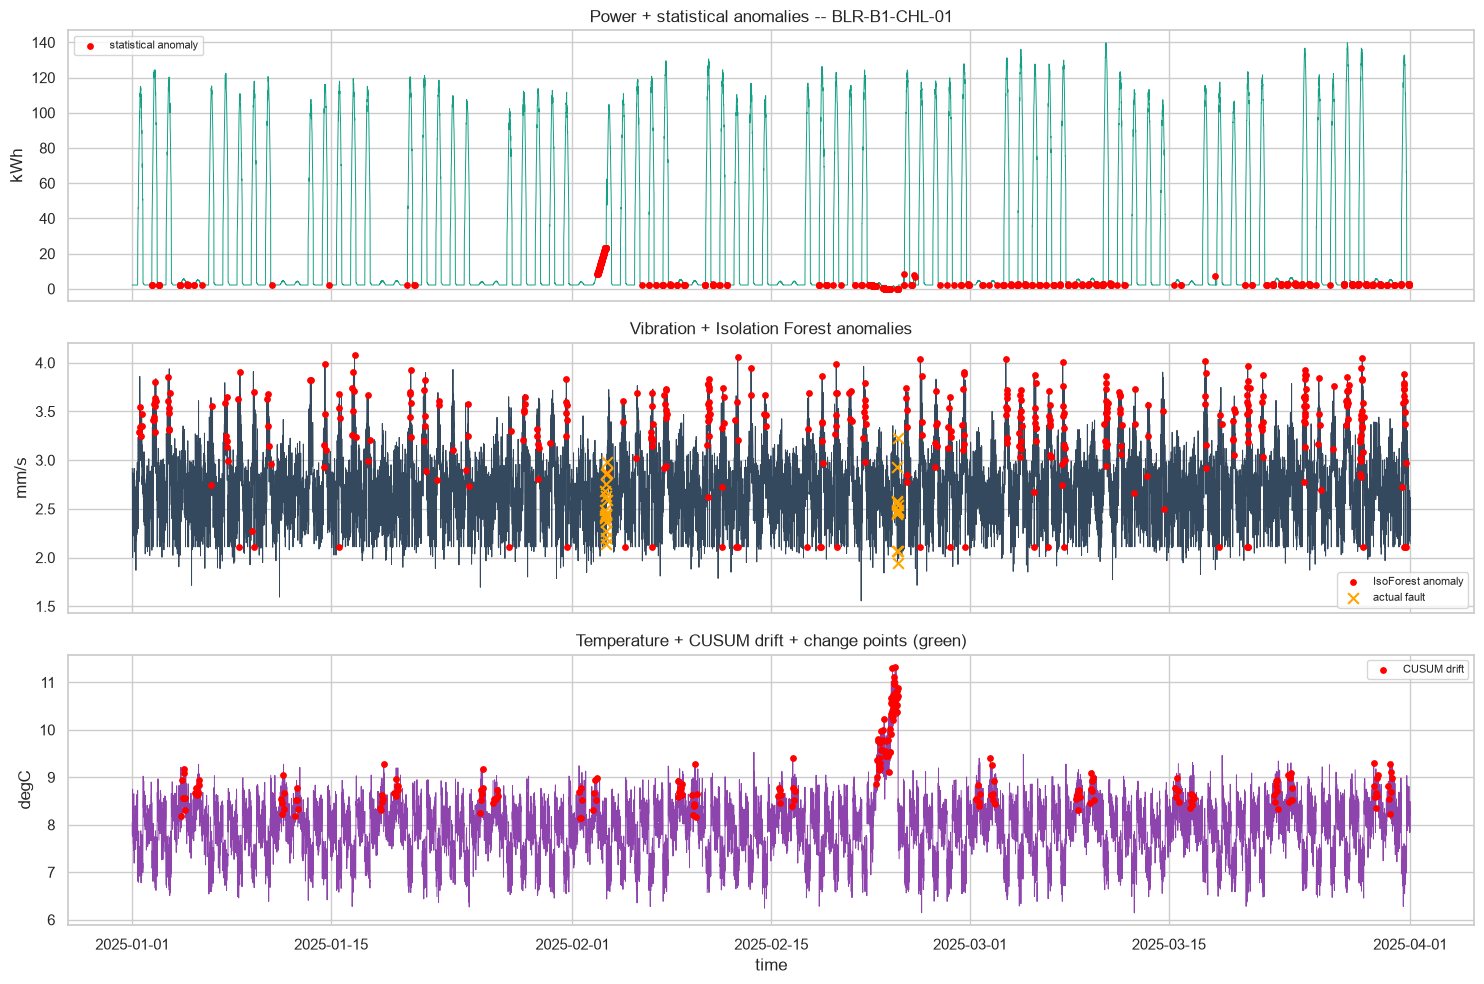

In [7]:
example_id = stat.loc[stat.asset_type=='Chiller', 'asset_id'].iloc[0]
ex_stat = stat[stat.asset_id==example_id].sort_values('timestamp').reset_index(drop=True)
ex_iso = iso[iso.asset_id==example_id].sort_values('timestamp').reset_index(drop=True)
ex_cusum = cusum[cusum.asset_id==example_id].sort_values('timestamp').reset_index(drop=True)
ex_cps = cps.get(example_id, [])

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
axes[0].plot(ex_stat['timestamp'], ex_stat['power_consumption'], color='#16a085', lw=0.7)
sp = ex_stat[ex_stat.stat_anomaly==1]
axes[0].scatter(sp['timestamp'], sp['power_consumption'], color='red', s=15, zorder=5, label='statistical anomaly')
axes[0].set(title=f'Power + statistical anomalies -- {example_id}', ylabel='kWh'); axes[0].legend(fontsize=8)

axes[1].plot(ex_iso['timestamp'], ex_iso['vibration'], color='#34495e', lw=0.7)
ip = ex_iso[ex_iso.iso_anomaly==1]
axes[1].scatter(ip['timestamp'], ip['vibration'], color='red', s=15, zorder=5, label='IsoForest anomaly')
ft = ex_iso[ex_iso.fault_flag==1]
axes[1].scatter(ft['timestamp'], ft['vibration'], color='orange', marker='x', s=60, zorder=6, label='actual fault')
axes[1].set(title='Vibration + Isolation Forest anomalies', ylabel='mm/s'); axes[1].legend(fontsize=8)

axes[2].plot(ex_cusum['timestamp'], ex_cusum['temperature'], color='#8e44ad', lw=0.7)
cp = ex_cusum[ex_cusum.cusum_anomaly==1]
axes[2].scatter(cp['timestamp'], cp['temperature'], color='red', s=15, zorder=5, label='CUSUM drift')
for t in ex_cps:
    axes[2].axvline(t, color='green', ls='--', lw=1, alpha=0.7)
axes[2].set(title='Temperature + CUSUM drift + change points (green)', ylabel='degC', xlabel='time')
axes[2].legend(fontsize=8)
plt.tight_layout(); plt.savefig(f'{FIG}/14_task4_anomalies.png', dpi=110); plt.show()

## 7. Combined export (for the dashboard)

In [8]:
iso_with_type = iso.merge(raw['metadata'][['asset_id','asset_type']], on='asset_id', how='left')
combined = iso_with_type[['timestamp','asset_id','site_id','building_id','asset_type',
                 'temperature','vibration','power_consumption','fault_flag',
                 'iso_anomaly','iso_score']].copy()
combined = combined.merge(
    stat[['timestamp','asset_id','stat_anomaly']], on=['timestamp','asset_id'], how='left')
combined = combined.merge(
    cusum[['timestamp','asset_id','cusum_anomaly']], on=['timestamp','asset_id'], how='left')
combined['any_anomaly'] = (combined[['iso_anomaly','stat_anomaly','cusum_anomaly']].fillna(0).sum(axis=1) > 0).astype(int)

out_path = os.path.join('..', 'dashboard', 'anomalies.csv')
os.makedirs(os.path.dirname(out_path), exist_ok=True)
combined.to_csv(out_path, index=False)
print(f"Saved {len(combined):,} rows -> {out_path}")
print(f"Any-method anomaly rate: {combined.any_anomaly.mean()*100:.2f}%")

Saved 1,023,840 rows -> ..\dashboard\anomalies.csv
Any-method anomaly rate: 6.35%


## 8. Business recommendations

1. **Route by severity, not just flag count** -- Isolation Forest's `iso_score` gives a
   continuous severity ranking; send the top-scoring events to technicians first rather
   than treating every flag equally.
2. **Use anomaly density as an early-warning trigger** -- the validated lift near known
   faults means a *cluster* of anomalies on one asset (not a single isolated flag) should
   trigger a maintenance inspection, complementing Task 2's model directly.
3. **CUSUM/change-point flags matter most on assets Task 2 scores as borderline** --
   these two methods catch slow-onset degradation that a snapshot-in-time classifier can
   miss between its rolling-window updates.
4. **Sensor-drift detection protects data quality platform-wide** -- a drifting sensor
   corrupts every downstream model (Tasks 2 and 3 both consume the same raw columns), so
   flagging it early preserves the whole pipeline's reliability, not just Task 4's own output.
5. **Tune thresholds per asset type** -- Chillers/Pumps/AHUs have different normal
   operating ranges (confirmed in the EDA); a single global threshold under- or
   over-triggers depending on equipment type, which is why every method here is applied
   per-asset, not pooled.